## Exploratory Data Analysis

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

### Perform basic EDA on the dataset

In [15]:


data_path = "../data/airfoil_self_noise-dataset.xlsx"
data = pd.read_excel(data_path)

print(data.head())

print("Dataset shape:", data.shape)

print("\nColumn names:")
print(data.columns)

print("\nData types:")
print(data.dtypes)

   frequency  attack-angle  chord-length  free-stream-velocity  \
0        800           0.0        0.3048                  71.3   
1       1000           0.0        0.3048                  71.3   
2       1250           0.0        0.3048                  71.3   
3       1600           0.0        0.3048                  71.3   
4       2000           0.0        0.3048                  71.3   

   suction-side-displacement-thickness  scaled-sound-pressure  
0                             0.002663                126.201  
1                             0.002663                125.201  
2                             0.002663                125.951  
3                             0.002663                127.591  
4                             0.002663                127.461  
Dataset shape: (1503, 6)

Column names:
Index(['frequency', 'attack-angle', 'chord-length', 'free-stream-velocity',
       'suction-side-displacement-thickness', 'scaled-sound-pressure'],
      dtype='object')

Data typ

In [16]:
print("Missing values:")
print(data.isnull().sum())

print("\nNumber of duplicate rows:")
print(data.duplicated().sum())

Missing values:
frequency                              0
attack-angle                           0
chord-length                           0
free-stream-velocity                   0
suction-side-displacement-thickness    0
scaled-sound-pressure                  0
dtype: int64

Number of duplicate rows:
0


          frequency  attack-angle  chord-length  free-stream-velocity  \
count   1503.000000   1503.000000   1503.000000           1503.000000   
mean    2886.380572      6.782302      0.136548             50.860745   
std     3152.573137      5.918128      0.093541             15.572784   
min      200.000000      0.000000      0.025400             31.700000   
25%      800.000000      2.000000      0.050800             39.600000   
50%     1600.000000      5.400000      0.101600             39.600000   
75%     4000.000000      9.900000      0.228600             71.300000   
max    20000.000000     22.200000      0.304800             71.300000   

       suction-side-displacement-thickness  scaled-sound-pressure  
count                          1503.000000            1503.000000  
mean                              0.011140             124.835943  
std                               0.013150               6.898657  
min                               0.000401             103.380000  
25

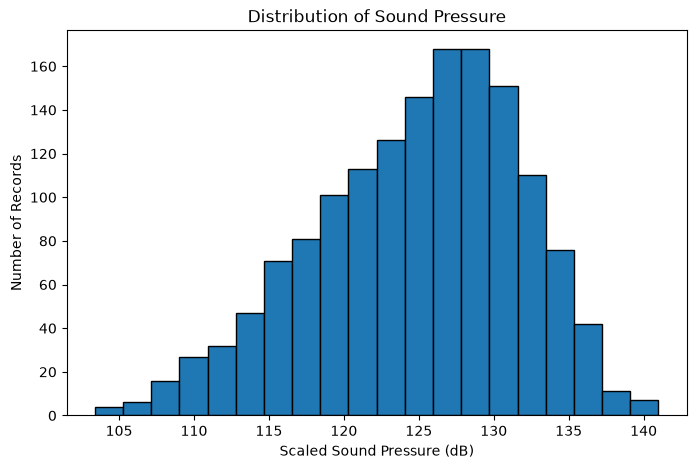

In [17]:
print(data.describe())

# Plot 1: Target histogram
plt.figure(figsize=(8, 5))

plt.hist(
    data["scaled-sound-pressure"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Sound Pressure")
plt.xlabel("Scaled Sound Pressure (dB)")
plt.ylabel("Number of Records")
plt.show()

/var/folders/dt/b6vw4kn526j854sqn496zkbc0000gn/T/ipykernel_15840/2701455040.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


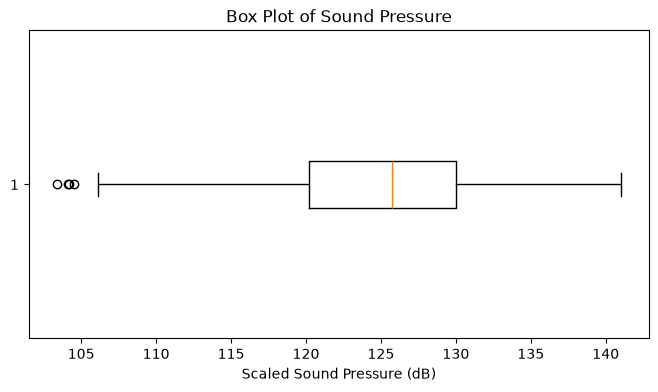

In [18]:
plt.figure(figsize=(8, 4))

plt.boxplot(
    data["scaled-sound-pressure"],
    vert=False
)

plt.title("Box Plot of Sound Pressure")
plt.xlabel("Scaled Sound Pressure (dB)")
plt.show()

frequency                             -0.390711
suction-side-displacement-thickness   -0.312670
chord-length                          -0.236162
attack-angle                          -0.156108
free-stream-velocity                   0.125103
scaled-sound-pressure                  1.000000
Name: scaled-sound-pressure, dtype: float64


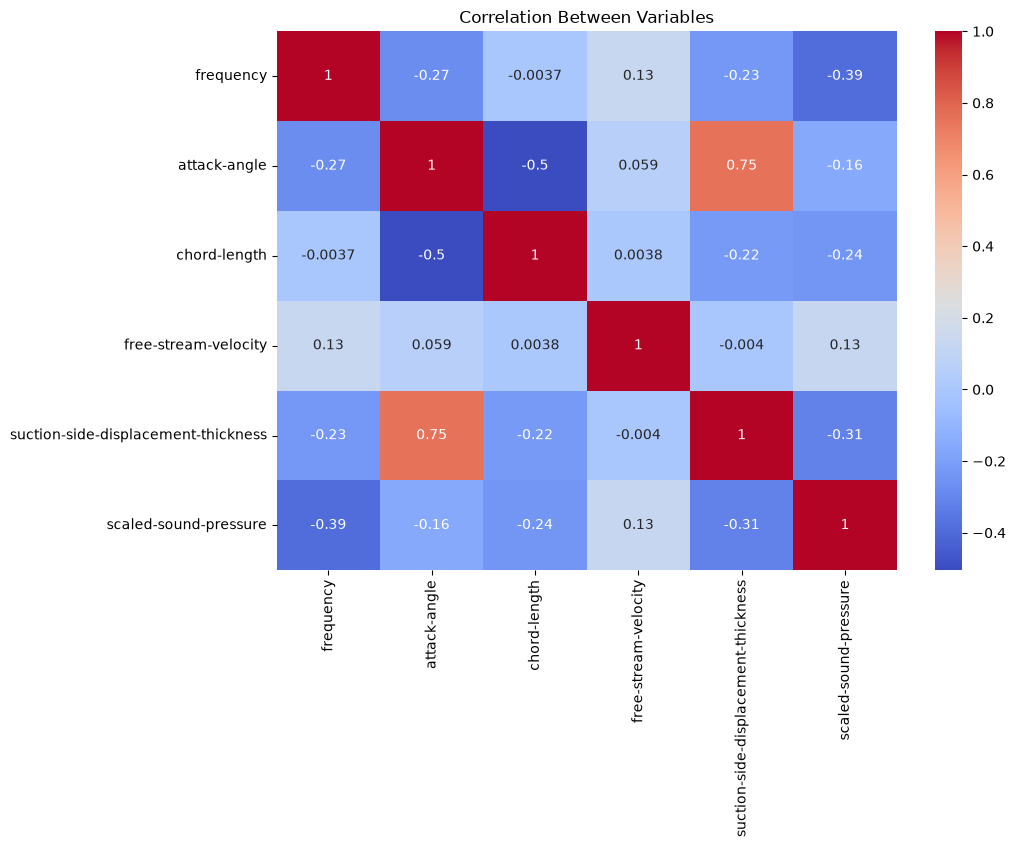

In [19]:
correlation = data.corr()

print(
    correlation["scaled-sound-pressure"]
    .sort_values()
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Variables")
plt.show()

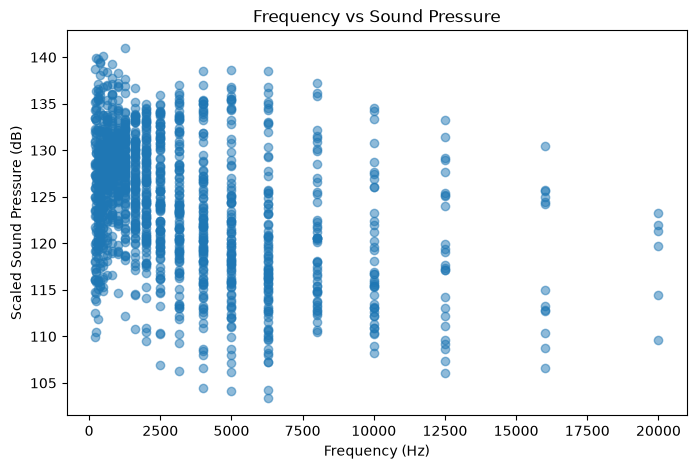

In [20]:
plt.figure(figsize=(8, 5))

plt.scatter(
    data["frequency"],
    data["scaled-sound-pressure"],
    alpha=0.5
)

plt.title("Frequency vs Sound Pressure")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Scaled Sound Pressure (dB)")
plt.show()

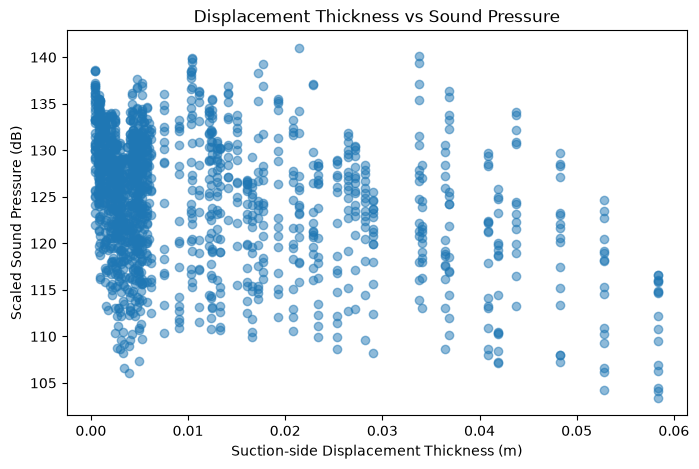

In [21]:
plt.figure(figsize=(8, 5))

plt.scatter(
    data["suction-side-displacement-thickness"],
    data["scaled-sound-pressure"],
    alpha=0.5
)

plt.title("Displacement Thickness vs Sound Pressure")
plt.xlabel("Suction-side Displacement Thickness (m)")
plt.ylabel("Scaled Sound Pressure (dB)")
plt.show()

### Short summary on EDA observations: 

1,503 observations, 5 input variables, 1 target variable: scaled-sound-pressure

No missing values, No duplicate rows, Numeric data types throughout

### Target variabla anysis:

Mean: 124.84 dB

Standard deviation: 6.90 dB

Minimum: 103.38 dB

Maximum: 140.99 dB

Middle 50%: approximately 120.19–130.00 dB


Frequency has the strongest individual linear relationship with sound pressure. In general, higher frequencies are associated with lower sound-pressure measurements.
Greater suction-side displacement thickness is also associated with lower sound pressure.
However, none of the correlations is especially strong. Sound pressure probably depends on combinations of variables and non-linear effects rather than one input alone.